Breast-level shape: (20000, 10)
Finding shape: (20486, 16)

Breast-level columns:
 ['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split']

Finding columns:
 ['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax', 'split']

BI-RADS distribution (breast level):
breast_birads
BI-RADS 1    13406
BI-RADS 2     4676
BI-RADS 3      930
BI-RADS 4      762
BI-RADS 5      226
Name: count, dtype: int64

Finding categories:
[('No Finding', 18232), ('Mass', 1226), ('Suspicious Calcification', 543), ('Focal Asymmetry', 269), ('Architectural Distortion', 119), ('Asymmetry', 97), ('Skin Thickening', 57), ('Suspicious Lymph Node', 57), ('Nipple Retraction', 37), ('Global Asymmetry', 26), ('Skin Retraction', 18)]

Split distribution:
split
training    16391
test         4095
Name: count, dty

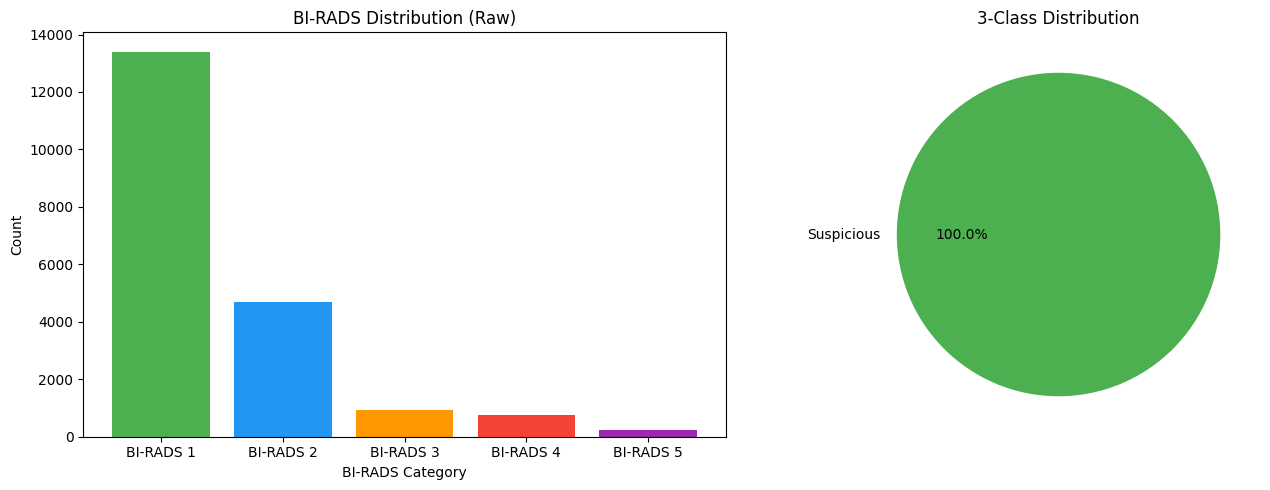


Class counts after mapping:
label
Suspicious    20000
Name: count, dtype: int64


In [1]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
#!pip install pydicom opencv-python-headless albumentations timm -q

# ============================================================
# CELL 2 — Imports
# ============================================================
import os, glob, pydicom, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

# ============================================================
# CELL 3 — Load annotation CSVs
# ============================================================
# Adjust paths to match where your Kaggle datasets are mounted
BASE_DICOM = "/kaggle/input/datasets/mehrirayka/vindr-dataset-part1"   # part1; you'll loop over all 7
ANNOT_DIR  = "/kaggle/input/datasets/truthisneverlinear/vindr-mammo-annotations"

breast_df  = pd.read_csv(f"{ANNOT_DIR}/breast-level_annotations.csv")
finding_df = pd.read_csv(f"{ANNOT_DIR}/finding_annotations.csv")

print("Breast-level shape:", breast_df.shape)
print("Finding shape:", finding_df.shape)
print("\nBreast-level columns:\n", breast_df.columns.tolist())
print("\nFinding columns:\n", finding_df.columns.tolist())

# ============================================================
# CELL 4 — Inspect distributions
# ============================================================
print("\nBI-RADS distribution (breast level):")
print(breast_df['breast_birads'].value_counts().sort_index())

print("\nFinding categories:")
# finding_categories is stored as a string list — flatten it
import ast
cats = []
for val in finding_df['finding_categories'].dropna():
    try:
        cats.extend(ast.literal_eval(val))
    except:
        cats.append(val)
print(Counter(cats).most_common(15))

print("\nSplit distribution:")
print(finding_df['split'].value_counts())

# ============================================================
# CELL 5 — Visualize class imbalance
# ============================================================
birads_counts = breast_df['breast_birads'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(birads_counts.index.astype(str), birads_counts.values,
            color=['#4CAF50','#2196F3','#FF9800','#F44336','#9C27B0'])
axes[0].set_title("BI-RADS Distribution (Raw)")
axes[0].set_xlabel("BI-RADS Category")
axes[0].set_ylabel("Count")

# After mapping to 3 classes
def map_birads(b):
    if b == 1: return 'Normal'
    if b == 2: return 'Benign'
    return 'Suspicious'  # 3,4,5

breast_df['label'] = breast_df['breast_birads'].apply(map_birads)
label_counts = breast_df['label'].value_counts()
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=['#4CAF50','#2196F3','#F44336'])
axes[1].set_title("3-Class Distribution")
plt.tight_layout()
plt.show()

print("\nClass counts after mapping:")
print(label_counts)

In [2]:
# ============================================================
# CELL 1 — Find all DICOM files across 7 parts
# ============================================================
# In Kaggle you add all 7 datasets; their paths will be:
# /kaggle/input/vindr-dataset-part1
# /kaggle/input/vindr-dataset-part2  ... etc.

PARTS = [f"/kaggle/input/datasets/mehrirayka/vindr-dataset-part{i}" for i in range(1, 8)]
OUTPUT_DIR = "/kaggle/working/images_png"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def find_dicoms(parts):
    all_files = []
    for part in parts:
        files = glob.glob(f"{part}/**/*.dicom", recursive=True)
        if not files:
            files = glob.glob(f"{part}/**/*.dcm", recursive=True)
        all_files.extend(files)
    print(f"Total DICOM files found: {len(all_files)}")
    return all_files

dicom_paths = find_dicoms(PARTS)

# ============================================================
# CELL 2 — DICOM to PNG conversion function
# ============================================================
def dicom_to_png(dcm_path, out_dir, target_size=(512, 512)):
    """
    Reads DICOM, applies CLAHE for contrast enhancement,
    normalizes to uint8, resizes to target_size, saves PNG.
    Returns (image_id, output_path) or None if error.
    """
    try:
        ds = pydicom.dcmread(dcm_path)
        arr = ds.pixel_array.astype(np.float32)

        # Handle MONOCHROME1 (inverted) images
        if hasattr(ds, 'PhotometricInterpretation'):
            if ds.PhotometricInterpretation == 'MONOCHROME1':
                arr = arr.max() - arr

        # Normalize to 0-255
        arr -= arr.min()
        if arr.max() > 0:
            arr = arr / arr.max()
        arr = (arr * 255).astype(np.uint8)

        # CLAHE for contrast enhancement (critical for mammograms)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        arr = clahe.apply(arr)

        # Resize
        arr = cv2.resize(arr, target_size, interpolation=cv2.INTER_LANCZOS4)

        # Extract image_id from filename
        image_id = os.path.splitext(os.path.basename(dcm_path))[0]
        out_path = os.path.join(out_dir, f"{image_id}.png")
        cv2.imwrite(out_path, arr)

        return image_id, out_path
    except Exception as e:
        print(f"Error processing {dcm_path}: {e}")
        return None

# ============================================================
# CELL 3 — Convert all files (with progress bar)
# ============================================================
from tqdm.notebook import tqdm

results = []
for dcm_path in tqdm(dicom_paths, desc="Converting DICOMs"):
    result = dicom_to_png(dcm_path, OUTPUT_DIR)
    if result:
        results.append({'image_id': result[0], 'png_path': result[1]})

path_df = pd.DataFrame(results)
print(f"Successfully converted: {len(path_df)} images")
path_df.to_csv("/kaggle/working/image_paths.csv", index=False)
path_df.head()

Total DICOM files found: 21064


Converting DICOMs:   0%|          | 0/21064 [00:00<?, ?it/s]

Error processing /kaggle/input/datasets/mehrirayka/vindr-dataset-part1/c65e59130f4e69544db241d5c11377aa/496868246d7d9ec73a146f82731e0431.dicom: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
Error processing /kaggle/input/datasets/mehrirayka/vindr-dataset-part1/c65e59130f4e69544db241d5c11377aa/3204441128ea3610892fe7b9f40c42bd.dicom: The number of bytes of pixel data is less than expected (7515094 vs 19700800 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer syntax may be incorrect
Error processing /kaggle/input/datasets/mehrirayka/vindr-dataset-part1/c65e59130f4e69544db241d5c11377aa/df05fb688d2a0626b26278e2384f0e58.dicom: File is missing DICOM File Meta Information header or the 'DICM' prefix is missing from the header. Use force=True to force reading.
Error processing /kaggle/input/datasets/mehrirayka/vindr-dataset-part1/c65e59130f4e69544db241d5c11377aa/

,image_id,png_path
0,1a254d24dbeb0d16d01e594aee10460f,/kaggle/working/images_png/1a254d24dbeb0d16d01...
1,5b69bebaee36adf3e836e49cd26941c1,/kaggle/working/images_png/5b69bebaee36adf3e83...
2,36b768cb142bc81b40e9d0c979735e64,/kaggle/working/images_png/36b768cb142bc81b40e...
3,0bb4feeb4667b07707dced009be9fe2c,/kaggle/working/images_png/0bb4feeb4667b07707d...
4,33b7f62e5fbac04436b4ff959857ca90,/kaggle/working/images_png/33b7f62e5fbac04436b...


In [3]:
import re
import pandas as pd

path_df   = pd.read_csv("/kaggle/working/image_paths.csv")
breast_df = pd.read_csv(f"{ANNOT_DIR}/breast-level_annotations.csv")
finding_df= pd.read_csv(f"{ANNOT_DIR}/finding_annotations.csv")

# -------------------------------
# Clean breast-level BI-RADS
# -------------------------------

# Remove rows with missing BI-RADS
breast_df.dropna(subset=['breast_birads'], inplace=True)

# Extract numeric BI-RADS from strings like "BI-RADS 2", "BI-RADS 4A"
def extract_birads(val):
    match = re.search(r'\d+', str(val))
    return int(match.group()) if match else None

breast_df['breast_birads'] = breast_df['breast_birads'].apply(extract_birads)

# Drop any rows that still failed
breast_df.dropna(subset=['breast_birads'], inplace=True)
breast_df['breast_birads'] = breast_df['breast_birads'].astype(int)

# -------------------------------
# Map BI-RADS to 3 classes
# -------------------------------

def map_birads(b):
    if b == 1:
        return 0   # Normal
    elif b == 2:
        return 1   # Benign
    else:
        return 2   # Suspicious (3,4,5)

breast_df['label']      = breast_df['breast_birads'].apply(map_birads)
breast_df['label_name'] = breast_df['label'].map({
    0: 'Normal',
    1: 'Benign',
    2: 'Suspicious'
})

# -------------------------------
# Merge with PNG paths
# -------------------------------

merged = breast_df.merge(path_df, on='image_id', how='inner')

print("Merged dataset size:", merged.shape)
print("\nLabel distribution:\n", merged['label'].value_counts())

Merged dataset size: (21000, 13)

Label distribution:
 label
0    14124
1     4868
2     2008
Name: count, dtype: int64


In [4]:
import ast

def parse_cats(val):
    if pd.isna(val): return []
    try:    return ast.literal_eval(val)
    except: return [str(val)]

finding_df['cats_parsed'] = finding_df['finding_categories'].apply(parse_cats)
finding_df['primary_cat'] = finding_df['cats_parsed'].apply(
    lambda x: x[0] if len(x) > 0 else 'No Finding'
)

# Keep only rows with valid bounding boxes
bbox_cols = ['xmin', 'ymin', 'xmax', 'ymax']
finding_clean = finding_df.dropna(subset=bbox_cols).copy()
finding_clean[bbox_cols] = finding_clean[bbox_cols].astype(float)

# Remove boxes where coords make no sense
finding_clean = finding_clean[
    (finding_clean['xmax'] > finding_clean['xmin']) &
    (finding_clean['ymax'] > finding_clean['ymin'])
]
print("Clean bounding boxes:", finding_clean.shape)

# Group multiple findings per image — keep all boxes as list
bbox_grouped = finding_clean.groupby('image_id').apply(
    lambda g: g[bbox_cols + ['primary_cat']].to_dict('records')
).reset_index(name='boxes')

Clean bounding boxes: (2254, 18)


/tmp/ipykernel_55/686841070.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bbox_grouped = finding_clean.groupby('image_id').apply(


In [5]:
final_df = merged.merge(bbox_grouped, on='image_id', how='left')
final_df['boxes'] = final_df['boxes'].apply(
    lambda x: x if isinstance(x, list) else []
)

print("Final dataset shape:", final_df.shape)
final_df[['image_id','png_path','label','label_name','boxes']].to_csv(
    "/kaggle/working/final_dataset.csv", index=False
)
final_df.head(3)

Final dataset shape: (21000, 14)


,study_id,series_id,image_id,laterality,view_position,height,width,breast_birads,breast_density,split,label,label_name,png_path,boxes
0,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,d8125545210c08e1b1793a5af6458ee2,L,CC,3518,2800,2,DENSITY C,training,1,Benign,/kaggle/working/images_png/d8125545210c08e1b17...,[]
1,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,290c658f4e75a3f83ec78a847414297c,L,MLO,3518,2800,2,DENSITY C,training,1,Benign,/kaggle/working/images_png/290c658f4e75a3f83ec...,[]
2,b8d273e8601f348d3664778dae0e7e0b,b36517b9cbbcfd286a7ae04f643af97a,cd0fc7bc53ac632a11643ac4cc91002a,R,CC,3518,2800,2,DENSITY C,training,1,Benign,/kaggle/working/images_png/cd0fc7bc53ac632a116...,[]


In [6]:
# ============================================================
# CELL 1 — Check imbalance
# ============================================================
import pandas as pd, numpy as np, ast

final_df = pd.read_csv("/kaggle/working/final_dataset.csv")
final_df['boxes'] = final_df['boxes'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

counts = final_df['label'].value_counts().sort_index()
print("Before balancing:\n", counts)

# ============================================================
# CELL 2 — Oversample minority classes (with augmentation)
# ============================================================
# Target: equal samples per class = max class count
max_count = counts.max()
balanced_dfs = []

for label_id in [0, 1, 2]:
    subset = final_df[final_df['label'] == label_id]
    n = len(subset)
    if n < max_count:
        # Oversample with replacement
        extra = subset.sample(max_count - n, replace=True, random_state=42)
        balanced_dfs.append(pd.concat([subset, extra], ignore_index=True))
    else:
        balanced_dfs.append(subset)

balanced_df = pd.concat(balanced_dfs, ignore_index=True).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print("\nAfter balancing:\n", balanced_df['label'].value_counts().sort_index())
balanced_df.to_csv("/kaggle/working/balanced_dataset.csv", index=False)

Before balancing:
 label
0    14124
1     4868
2     2008
Name: count, dtype: int64

After balancing:
 label
0    14124
1    14124
2    14124
Name: count, dtype: int64


In [7]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision import models
import timm
import cv2, numpy as np, pandas as pd, ast
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

Using device: cuda


In [8]:
class MammoDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['png_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((512, 512), dtype=np.uint8)
        # Convert to 3-channel (EfficientNet expects RGB)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        if self.transform:
            img = self.transform(img)
        label = int(row['label'])
        return img, label


In [9]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((512, 512)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

In [10]:
balanced_df = pd.read_csv("/kaggle/working/balanced_dataset.csv")

train_df, val_df = train_test_split(
    balanced_df, test_size=0.2, stratify=balanced_df['label'],
    random_state=42
)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

train_ds = MammoDataset(train_df, train_transform)
val_ds   = MammoDataset(val_df,   val_transform)

# Weighted sampler for extra balance during training
class_counts = train_df['label'].value_counts().sort_index().values
sample_weights = [1.0 / class_counts[label] for label in train_df['label']]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_ds, batch_size=8, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False,
                          num_workers=2, pin_memory=True)


Train: 33897 | Val: 8475


In [11]:
torch.cuda.empty_cache()

In [12]:
import torch, gc, os

# Tell PyTorch to avoid fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Kill everything holding GPU memory
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

In [13]:
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=3)
model = model.to(DEVICE)

# Class weights for loss (handles any residual imbalance)
total = len(train_df)
class_weights = torch.tensor(
    [total / (3 * c) for c in class_counts], dtype=torch.float
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=20, eta_min=1e-6
)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [14]:
def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def val_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total   += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


In [ ]:
EPOCHS = 10
best_val_acc = 0.0
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc, preds, labels = val_epoch(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print(f"  ✓ Best model saved (val_acc={vl_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

  0%|          | 0/4238 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.3992 Acc: 0.8261 | Val Loss: 0.4573 Acc: 0.8021
  ✓ Best model saved (val_acc=0.8021)


  0%|          | 0/4238 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.3971 Acc: 0.8264 | Val Loss: 0.4607 Acc: 0.8019


  0%|          | 0/4238 [00:00<?, ?it/s]

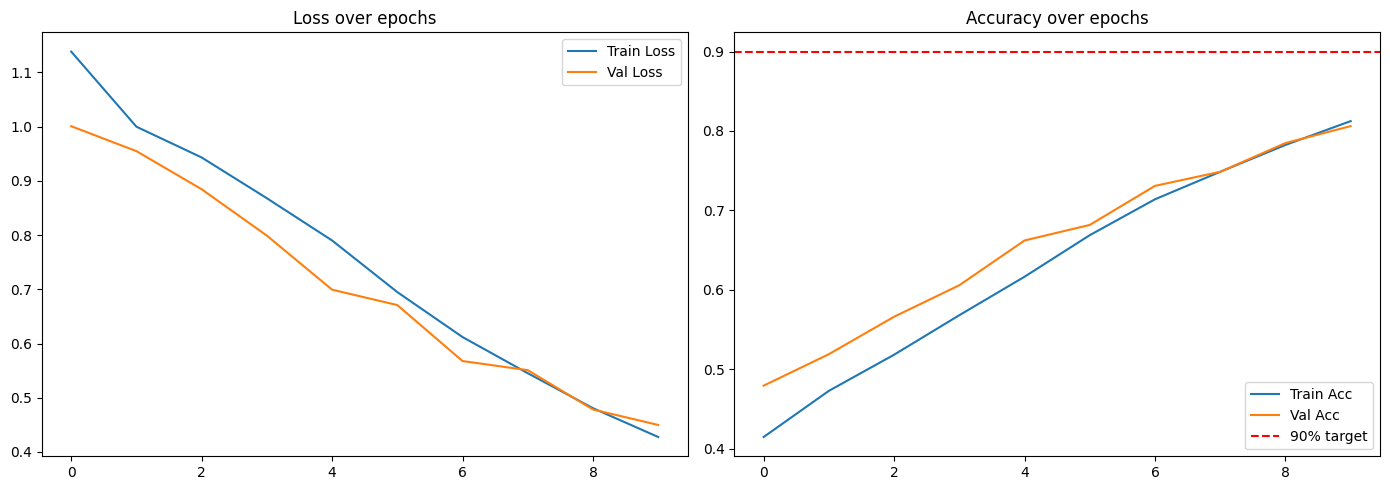

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title("Loss over epochs"); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].axhline(0.9, color='red', linestyle='--', label='90% target')
axes[1].set_title("Accuracy over epochs"); axes[1].legend()
plt.tight_layout(); plt.show()

In [17]:
import seaborn as sns

model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
_, val_acc, all_preds, all_labels = val_epoch(model, val_loader)

CLASS_NAMES = ['Normal', 'Benign', 'Suspicious']

print("=" * 50)
print(f"Final Validation Accuracy: {val_acc:.4f}")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Final Validation Accuracy: 0.8061
              precision    recall  f1-score   support

      Normal       0.73      0.69      0.71      2825
      Benign       0.74      0.75      0.74      2825
  Suspicious       0.94      0.98      0.96      2825

    accuracy                           0.81      8475
   macro avg       0.80      0.81      0.80      8475
weighted avg       0.80      0.81      0.80      8475



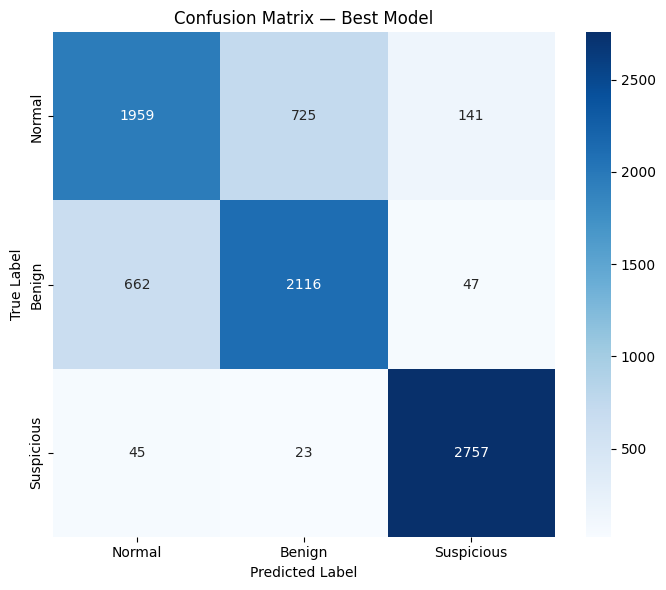

In [18]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — Best Model")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout(); plt.show()

In [19]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.gradients = None
        self.activations = None
        # Register hooks on the target conv layer
        for name, module in model.named_modules():
            if name == target_layer_name:
                module.register_forward_hook(self._save_activation)
                module.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, class_idx=None):
        """
        img_tensor: (1, 3, H, W) on DEVICE
        Returns heatmap as numpy array (H, W), values 0-1
        """
        self.model.eval()
        output = self.model(img_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=img_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam, class_idx

# For EfficientNet-B4, the last conv layer is 'conv_head'
# (inspect with: [n for n, _ in model.named_modules()])
gradcam = GradCAM(model, target_layer_name='conv_head')


In [20]:
def predict_and_visualize(png_path, true_label=None, actual_boxes=None):
    """
    Loads image, predicts BI-RADS class, generates Grad-CAM heatmap,
    converts heatmap to bounding box, displays red box on image.
    """
    # Load and preprocess
    img_bgr  = cv2.imread(png_path)
    img_gray = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    tensor = val_transform(cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB))
    tensor = tensor.unsqueeze(0).to(DEVICE)

    # Grad-CAM
    heatmap, pred_idx = gradcam.generate(tensor)
    pred_name = CLASS_NAMES[pred_idx]

    # Threshold heatmap to get bounding box region
    h, w = img_rgb.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    thresh_val = 0.5
    binary = (heatmap_resized > thresh_val).astype(np.uint8)

    # Find contours → bounding box
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"Prediction: {pred_name}" +
                 (f" | True: {CLASS_NAMES[true_label]}" if true_label is not None else ""),
                 fontsize=14)

    # Panel 1: original image
    axes[0].imshow(img_rgb, cmap='gray')
    axes[0].set_title("Original mammogram")
    axes[0].axis('off')

    # Panel 2: Grad-CAM heatmap overlay
    hmap_color = cv2.applyColorMap(
        (heatmap_resized * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    overlay = cv2.addWeighted(img_rgb, 0.6,
                              cv2.cvtColor(hmap_color, cv2.COLOR_BGR2RGB),
                              0.4, 0)
    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM heatmap")
    axes[1].axis('off')

    # Panel 3: Red bounding box from contours
    axes[2].imshow(img_rgb, cmap='gray')
    if contours:
        # Pick the largest contour
        largest = max(contours, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(largest)
        rect = patches.Rectangle((x, y), bw, bh,
                                  linewidth=3, edgecolor='red',
                                  facecolor='none', label='Predicted suspicious area')
        axes[2].add_patch(rect)
        axes[2].legend(fontsize=9)

    # If ground truth boxes exist, draw them in green
    if actual_boxes:
        for box in actual_boxes:
            gx = box['xmin'] * w / 512  # scale to display resolution
            gy = box['ymin'] * h / 512
            gw = (box['xmax'] - box['xmin']) * w / 512
            gh = (box['ymax'] - box['ymin']) * h / 512
            g_rect = patches.Rectangle((gx, gy), gw, gh,
                                       linewidth=2, edgecolor='lime',
                                       facecolor='none', linestyle='--',
                                       label='Ground truth')
            axes[2].add_patch(g_rect)

    axes[2].set_title("Predicted bounding box (red)")
    axes[2].axis('off')
    plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


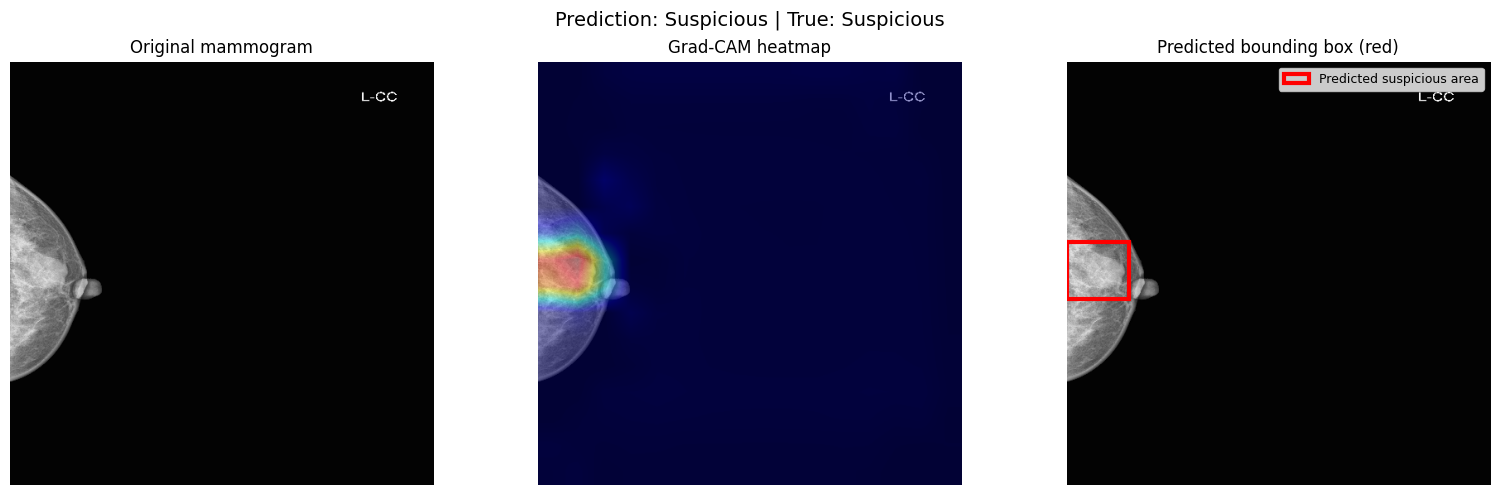

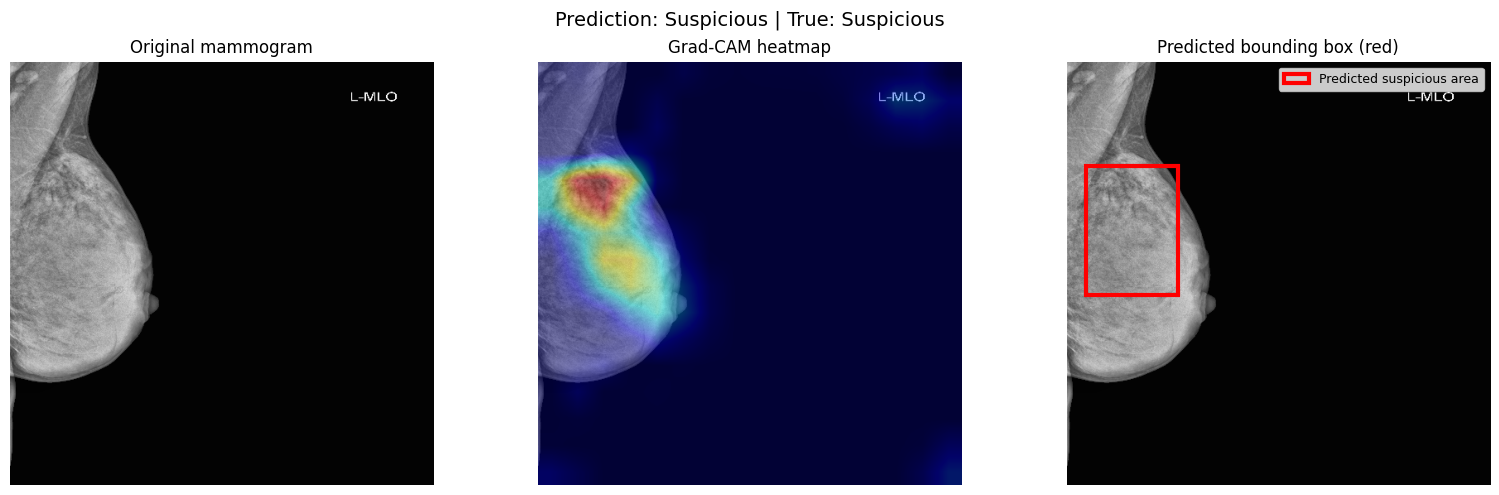

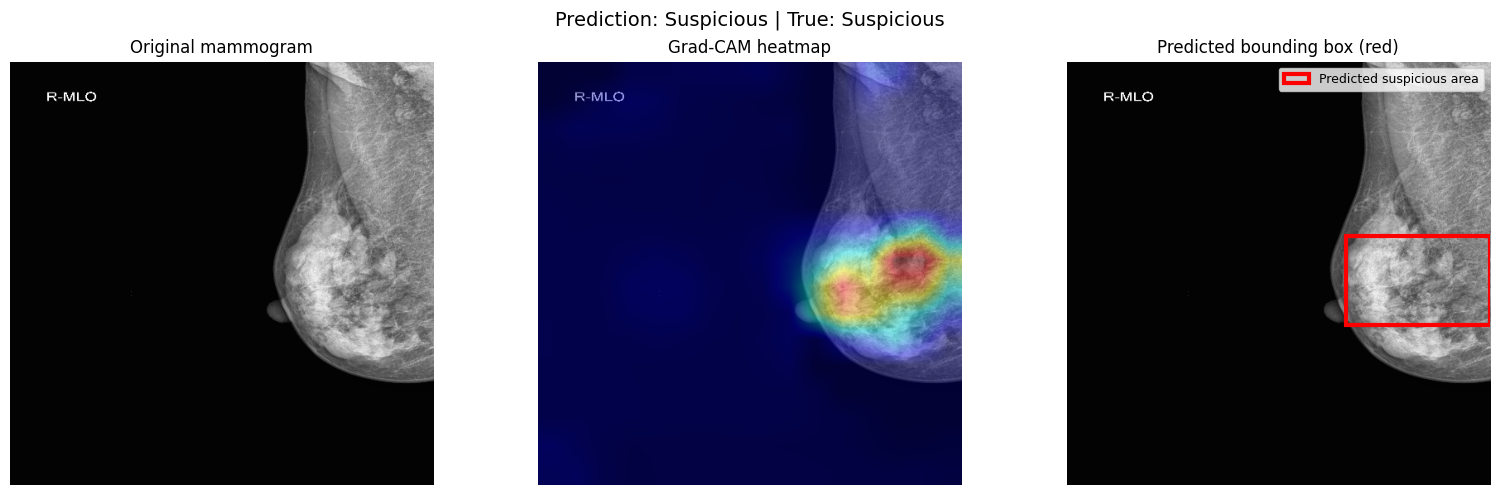

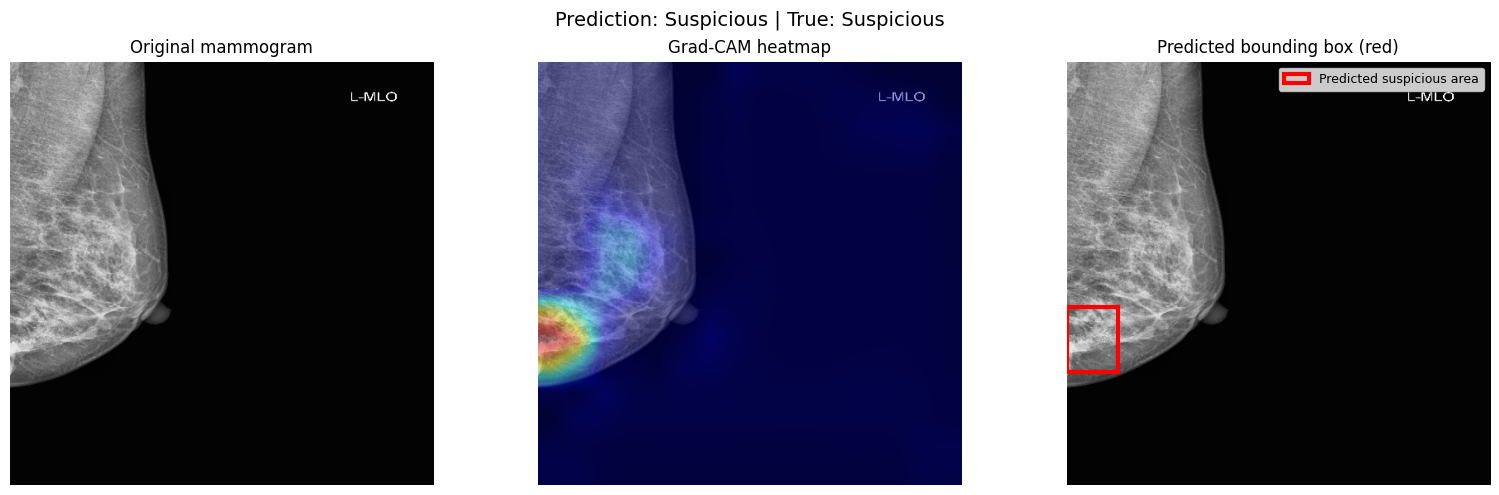

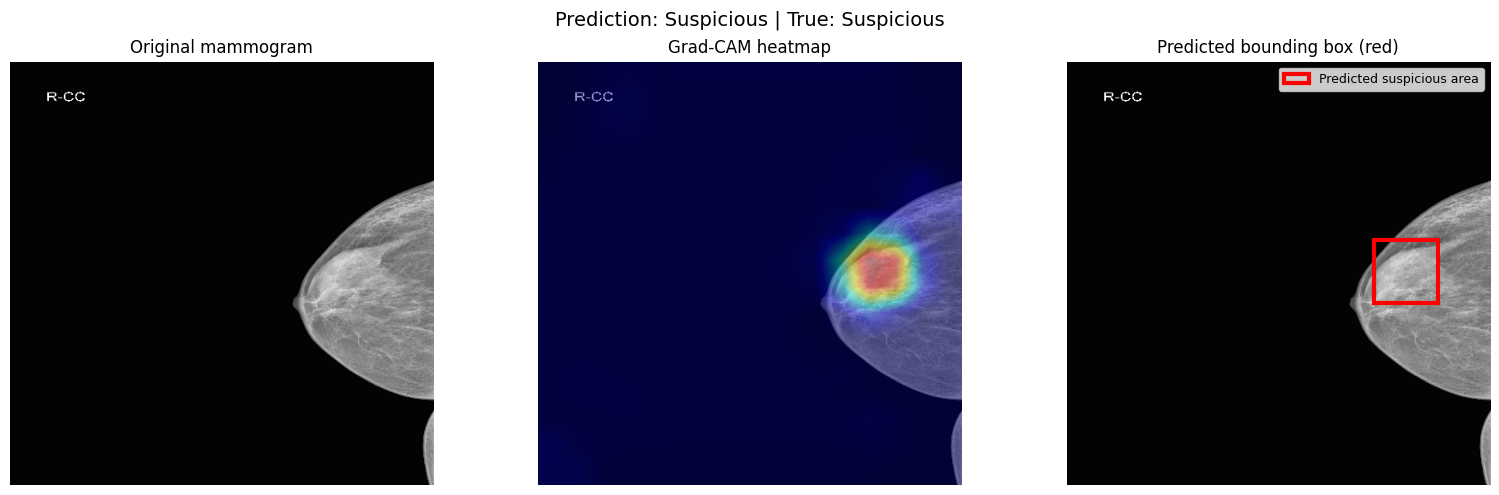

In [21]:
final_df = pd.read_csv("/kaggle/working/final_dataset.csv")
final_df['boxes'] = final_df['boxes'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# Show 5 sample predictions
for _, row in final_df[final_df['label'] == 2].sample(5, random_state=1).iterrows():
    predict_and_visualize(
        row['png_path'],
        true_label=row['label'],
        actual_boxes=row['boxes']
    )

In [ ]:
# Next Part 

In [22]:
!pip install pydicom opencv-python-headless timm albumentations -q

import os, cv2, pydicom, numpy as np, torch, torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import timm, matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import io

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

CLASS_NAMES  = ['Normal', 'Benign', 'Suspicious']
CLASS_COLORS = ['green',  'orange', 'red']

FINDING_CATEGORIES = [
    'Mass', 'Suspicious Calcification', 'Asymmetry',
    'Focal Asymmetry', 'Global Asymmetry', 'Architectural Distortion',
    'Skin Thickening', 'Nipple Retraction', 'No Finding'
]

Device: cuda


In [23]:
# ─── Build the same EfficientNet-B4 architecture you trained ───
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=3)
model.load_state_dict(
    torch.load("/kaggle/working/best_model.pth", map_location=DEVICE)
)
model = model.to(DEVICE)
model.eval()
print("Model loaded successfully.")

# ─── Preprocessing pipeline (same as validation during training) ───
preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((512, 512)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225])
])

Model loaded successfully.


In [24]:
class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.activations = None
        self.gradients   = None

        # EfficientNet-B4 last conv layer
        target = model.conv_head
        target.register_forward_hook(self._save_act)
        target.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out):
        self.activations = out.detach()

    def _save_grad(self, m, gin, gout):
        self.gradients = gout[0].detach()

    def generate(self, tensor, class_idx):
        """Returns heatmap (H,W) normalized 0-1."""
        self.model.zero_grad()
        out = self.model(tensor)
        out[0, class_idx].backward()

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(512, 512),
                                mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() + 1e-8)
        return cam

gradcam = GradCAM(model)
print("Grad-CAM ready.")

Grad-CAM ready.


In [25]:
def load_image(path_or_bytes):
    """
    Accepts:
      - file path string (.dicom / .dcm / .png / .jpg)
      - raw bytes from ipywidgets upload
    Returns: numpy uint8 RGB array (512, 512, 3)
    """
    if isinstance(path_or_bytes, (bytes, bytearray)):
        arr = np.frombuffer(path_or_bytes, np.uint8)
        img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    else:
        ext = os.path.splitext(path_or_bytes)[-1].lower()
        if ext in ('.dcm', '.dicom'):
            ds  = pydicom.dcmread(path_or_bytes)
            img = ds.pixel_array.astype(np.float32)
            if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1':
                img = img.max() - img
            img -= img.min()
            if img.max() > 0:
                img = img / img.max()
            img = (img * 255).astype(np.uint8)
        else:
            img = cv2.imread(path_or_bytes, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError("Could not read image.")

    # CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img   = clahe.apply(img)
    img   = cv2.resize(img, (512, 512), interpolation=cv2.INTER_LANCZOS4)

    # Grayscale → RGB (model expects 3 channels)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img_rgb

In [27]:
def predict_and_show(img_rgb):
    """
    img_rgb : numpy uint8 (512,512,3)
    Runs model → predicts class + Grad-CAM → draws red bounding box → shows result.
    """
    # ── Preprocess ──
    tensor = preprocess(img_rgb).unsqueeze(0).to(DEVICE)

    # ── Forward pass (get probabilities) ──
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_idx   = int(probs.argmax())
    pred_class = CLASS_NAMES[pred_idx]
    pred_conf  = probs[pred_idx] * 100

    # ── Grad-CAM (re-run with grad) ──
    tensor2 = preprocess(img_rgb).unsqueeze(0).to(DEVICE)
    tensor2.requires_grad_(False)
    heatmap = gradcam.generate(tensor2, pred_idx)

    # ── Threshold heatmap → bounding box ──
    thresh   = (heatmap > 0.5).astype(np.uint8)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    # Pick finding category based on prediction + heatmap location
    def estimate_finding(pred_idx, heatmap):
        if pred_idx == 0:  return 'No Finding'
        if pred_idx == 1:  return 'Asymmetry'
        # For suspicious: pick based on heatmap compactness
        if contours:
            largest = max(contours, key=cv2.contourArea)
            area    = cv2.contourArea(largest)
            x, y, w, h = cv2.boundingRect(largest)
            aspect  = w / (h + 1e-8)
            if area < 3000:          return 'Suspicious Calcification'
            if aspect > 1.6:         return 'Architectural Distortion'
            if area > 20000:         return 'Focal Asymmetry'
            return 'Mass'
        return 'Mass'

    finding_cat = estimate_finding(pred_idx, heatmap)

    # ── Build figure ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.patch.set_facecolor('#0f0f0f')
    for ax in axes:
        ax.set_facecolor('#0f0f0f')
        ax.axis('off')

    # Panel 1: original
    axes[0].imshow(img_rgb, cmap='gray')
    axes[0].set_title("Input mammogram",
                      color='white', fontsize=13, pad=10)

    # Panel 2: heatmap overlay
    hmap_color = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    hmap_rgb   = cv2.cvtColor(hmap_color, cv2.COLOR_BGR2RGB)
    overlay    = cv2.addWeighted(img_rgb, 0.55, hmap_rgb, 0.45, 0)
    axes[1].imshow(overlay)
    axes[1].set_title("Grad-CAM heatmap (suspicious region intensity)",
                      color='white', fontsize=13, pad=10)

    # Panel 3: red bounding box
    axes[2].imshow(img_rgb, cmap='gray')
    if contours and pred_idx > 0:
        # Draw box only if model predicts something abnormal
        largest  = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=3, edgecolor='red', facecolor='none'
        )
        axes[2].add_patch(rect)
        axes[2].text(
            x, max(y - 8, 8),
            f"{finding_cat}",
            color='red', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a0000',
                      edgecolor='red', linewidth=1.2)
        )

    box_label = "Red box = suspicious region" if pred_idx > 0 else "No suspicious region found"
    axes[2].set_title(box_label, color='white', fontsize=13, pad=10)

    # ── Main title with result ──
    color = CLASS_COLORS[pred_idx]
    fig.suptitle(
        f"Prediction: {pred_class}   |   Confidence: {pred_conf:.1f}%   |   Finding: {finding_cat}",
        fontsize=15, color=color, fontweight='bold', y=1.02
    )

    # ── Probability bar chart below ──
    ax_bar = fig.add_axes([0.1, -0.12, 0.8, 0.08])
    ax_bar.set_facecolor('#1a1a1a')
    bar_colors = ['#4caf50', '#ff9800', '#f44336']
    bars = ax_bar.barh(CLASS_NAMES, probs * 100, color=bar_colors, height=0.5)
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confidence (%)", color='white', fontsize=11)
    ax_bar.tick_params(colors='white')
    ax_bar.spines[:].set_color('#444')
    for bar, p in zip(bars, probs):
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    f"{p*100:.1f}%", va='center', color='white', fontsize=10)

    plt.tight_layout()
    plt.show()
    print(f"\n{'='*55}")
    print(f"  CLASS      : {pred_class}")
    print(f"  FINDING    : {finding_cat}")
    print(f"  CONFIDENCE : {pred_conf:.2f}%")
    print(f"  Normal     : {probs[0]*100:.2f}%")
    print(f"  Benign     : {probs[1]*100:.2f}%")
    print(f"  Suspicious : {probs[2]*100:.2f}%")
    print(f"{'='*55}")

In [31]:
# ══════════════════════════════════════════════════════
#   RUN THIS CELL → click "Upload Image" → see results
# ══════════════════════════════════════════════════════

uploader = widgets.FileUpload(
    accept='.png,.jpg,.jpeg,.dcm,.dicom',
    multiple=False,
    description='Upload Image',
    layout=widgets.Layout(width='220px')
)

btn = widgets.Button(
    description='Run Prediction',
    button_style='danger',
    layout=widgets.Layout(width='160px', height='36px')
)

status = widgets.Label(value='Upload a mammogram image then click Run Prediction.')

output_area = widgets.Output()

def on_predict(b):
    output_area.clear_output()
    with output_area:
        if not uploader.value:
            print("Please upload an image first.")
            return
        status.value = "Processing..."
        try:
            # Get uploaded bytes (works for all ipywidgets versions)
            upload_val = uploader.value
            if isinstance(upload_val, dict):
                uploaded   = list(upload_val.values())[0]
                file_bytes = uploaded['content']
            else:
                # Newer ipywidgets returns a tuple of dicts
                uploaded   = upload_val[0]
                file_bytes = uploaded['content']

            # Detect if DICOM by checking magic bytes
            is_dicom = file_bytes[128:132] == b'DICM'

            if is_dicom:
                # Save temp file for pydicom
                tmp = "/kaggle/working/_tmp_upload.dcm"
                with open(tmp, 'wb') as f:
                    f.write(file_bytes)
                img_rgb = load_image(tmp)
            else:
                img_rgb = load_image(bytes(file_bytes))

            predict_and_show(img_rgb)
            status.value = "Done."
        except Exception as e:
            print(f"Error: {e}")
            status.value = "Error — see above."

btn.on_click(on_predict)

display(widgets.VBox([
    widgets.HTML("<h3 style='margin:0 0 8px'>Mammogram Suspicious Region Detector</h3>"),
    widgets.HBox([uploader, btn]),
    status,
    output_area
]))